# SAHH Subset Fitting Example

This notebook demonstrates the current `Handler` and subset-aware `BetterFitter` APIs on the SAHH ASM dataset. It loads the raw data, defines analytes and fitting windows, loads initial conditions, registers three fitting subsets inspired by `pseudo.py`, fits each subset, and converts the posterior areas into a combined timecourse.


In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

import chromhandler as ch
from chromhandler.annotations import PeakAnnotation, BaselineAnnotation
from chromhandler.fitting import BetterFitter

In [3]:
DATA_DIR = Path("/Users/max/code/sahh-kinetics-hplc/data")

handler = ch.Handler.read(path=DATA_DIR / "asm")
handler.cut_chromatograms((2.5, 3.6))

handler.samples = handler.samples[:2]


loaded_sample_ids = [sample.id for sample in handler.samples]
chromatogram_count = sum(len(sample.chromatograms) for sample in handler.samples)

print(f"Loaded {len(loaded_sample_ids)} samples and {chromatogram_count} chromatograms.")
print("Samples:", loaded_sample_ids)

handler.load_initial_conditions(
    DATA_DIR / "conditions.csv",
    conc_unit="umol / l",
)


Loaded 2 samples and 14 chromatograms.
Samples: ['CV10', 'CV11']


In [4]:
ino = handler.create_molecule(
    id="Ino",
    pubchem_cid=135398641,
    name="Inosine",
)
sih = handler.create_molecule(
    id="SIH",
    pubchem_cid=135398693,
    name="S-inosyl-L-homocysteine",
)
hyp = handler.create_molecule(
    id="Hyp",
    pubchem_cid=790,
    name="Hypoxanthine",
)

In [5]:
# SUBSET1_FULL_SAMPLES = ["CV10", "CV11", "CV12"]#, "CV13", "CV6", "CV7", "CV8", "CV9"]
# all_sample_ids = [sample.id for sample in handler.samples if sample.chromatograms]
# subset1_full_samples = [sample_id for sample_id in SUBSET1_FULL_SAMPLES if sample_id in all_sample_ids]
# remaining_samples = [sample_id for sample_id in all_sample_ids if sample_id not in subset1_full_samples]

# def chrom_ids_for_times(sample_ids: list[str], times: list[float]) -> list[str]:
#     chromatogram_ids: list[str] = []
#     for sample in handler.samples:
#         if sample.id not in sample_ids:
#             continue
#         for chrom in sample.chromatograms:
#             if chrom.reaction_time is not None and float(chrom.reaction_time) in times:
#                 chromatogram_ids.append(chrom.id)
#     return chromatogram_ids

# subset1_early_chrom_ids = chrom_ids_for_times(remaining_samples, [0.0, 10.0])
# subset2_base_chrom_ids = chrom_ids_for_times(remaining_samples, [20.0, 30.0, 60.0])
# subset3_chrom_ids = chrom_ids_for_times(remaining_samples, [120.0, 240.0])

fitter = BetterFitter.from_handler(handler)


# Subset 1: full samples + early time points (original peak annotations)

fitter.add_peak_annotation(PeakAnnotation(molecule_id="Inosine", rt_min=2.6, rt_max=2.85, mode="single"))
fitter.add_peak_annotation(
    PeakAnnotation(
        molecule_id="S-inosyl-L-homocysteine",
        rt_min=2.85,
        rt_max=3.15,
        mode="artefact_doublet",
        artefact_side="right",
    )
)
fitter.add_peak_annotation(
    PeakAnnotation(
        molecule_id="Hypoxanthine",
        rt_min=3.15,
        rt_max=3.48,
        mode="artefact_doublet",
        artefact_side="left",
        include_artefact_in_area=True,
    )
)
fitter.add_baseline_annotation(BaselineAnnotation(rt_min=2.58, rt_max=2.6))
fitter.add_baseline_annotation(BaselineAnnotation(rt_min=3.5, rt_max=3.52))


In [6]:
# fig, axes = fitter.plot_sigma_alpha_prior_diagnostics(
#     figsize=(15, 5),
#     label_fontsize=18,
#     marker_size=100,
#     title_fontsize=18,
#     spine_linewidth=2,
#     tick_fontsize=16,
#     marker_linewidth=2,
#     show_prior_density=False,
# )
# # Set consistent axis size and customize titles


In [7]:
fitter.fit(
    num_warmup=500,
    num_samples=500,
    num_chains=8,
    seed=42,
)

/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/jax/_src/api_util.py:440: UserWarning: Missing a plate statement for batch dimension -1 at site 'area_dominant'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/jax/_src/api_util.py:440: UserWarning: Missing a plate statement for batch dimension -1 at site 'area_artefact_trace_offset'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide

================================================================================

ArviZ Posterior Summary

================================================================================

mean        sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
trace_shift[0]                 0.009     0.000     0.008     0.009      0.000    0.000      19.0      37.0   1.34
trace_shift[1]                 0.002     0.000     0.001     0.002      0.000    0.000      27.0      30.0   1.21
trace_shift[2]                 0.009     0.000     0.009     0.010      0.000    0.000      13.0      93.0   1.69
trace_shift[3]                -0.011     0.000    -0.012    -0.010      0.000    0.000      15.0     129.0   1.52
trace_shift[4]                -0.001     0.017    -0.024     0.018      0.006    0.001      11.0      24.0   2.09
trace_shift[5]                 0.005     0.004     0.001     0.010      0.001    0.000      11.0      24.0   2.07
trace_shift[6]                 0.003     0.003    -0.000     0.007      0.001    0.000      11.0      25.0   2.06
trace_shift[7]                 0.006     0.000     0.005     0.006      0.000    0.000      16.0      31.0   1.45
trace_shift[8]                 0.008     0.001     0.007     0.009      0.000    0.000      12.0      23.0   1.83
trace_shift[9]                 0.007     0.002     0.004     0.011      0.001    0.000      11.0      24.0   2.08
trace_shift[10]               -0.015     0.000    -0.016    -0.015      0.000    0.000      15.0      44.0   1.50
trace_shift[11]               -0.032     0.001    -0.034    -0.029      0.000    0.000      16.0     124.0   1.42
trace_shift[12]                0.006     0.003     0.002     0.010      0.001    0.000      11.0      23.0   2.06
trace_shift[13]                0.005     0.003     0.002     0.009      0.001    0.000      11.0      25.0   2.05
apex[0, 0]                     2.719     0.000     2.719     2.720      0.000    0.000      19.0      37.0   1.34
apex[0, 1]                     3.004     0.000     3.003     3.005      0.000    0.000      19.0      37.0   1.34
apex[0, 2]                     3.309     0.000     3.308     3.309      0.000    0.000      19.0      37.0   1.34
apex[1, 0]                     2.712     0.000     2.712     2.713      0.000    0.000      27.0      30.0   1.21
apex[1, 1]                     2.997     0.000     2.996     2.997      0.000    0.000      27.0      30.0   1.21
apex[1, 2]                     3.302     0.000     3.301     3.302      0.000    0.000      27.0      30.0   1.21
apex[2, 0]                     2.720     0.000     2.719     2.721      0.000    0.000      13.0      93.0   1.69
apex[2, 1]                     3.005     0.000     3.004     3.005      0.000    0.000      13.0      93.0   1.69
apex[2, 2]                     3.309     0.000     3.309     3.310      0.000    0.000      13.0      93.0   1.69
apex[3, 0]                     2.700     0.000     2.699     2.701      0.000    0.000      15.0     129.0   1.52
apex[3, 1]                     2.984     0.000     2.984     2.985      0.000    0.000      15.0     129.0   1.52
apex[3, 2]                     3.289     0.000     3.288     3.290      0.000    0.000      15.0     129.0   1.52
apex[4, 0]                     2.710     0.017     2.686     2.729      0.006    0.001      11.0      24.0   2.09
apex[4, 1]                     2.994     0.017     2.971     3.013      0.006    0.001      11.0      24.0   2.09
apex[4, 2]                     3.299     0.017     3.276     3.318      0.006    0.001      11.0      24.0   2.09
apex[5, 0]                     2.716     0.004     2.712     2.721      0.001    0.000      11.0      24.0   2.07
apex[5, 1]                     3.001     0.004     2.996     3.005      0.001    0.000      11.0      24.0   2.07
apex[5, 2]                     3.305     0.004     3.301     3.310      0.001    0.000      11.0      24.0   2.07
apex[6, 0]                     2.714     0.003     2.710     2.718      0.001    0.000      11.0      25.0   2.06
apex[6, 1]                     2.999     0.003     2.995     3.002      0.001    0.000      11.0      25.0   2.06
apex[6, 2]                     3.303     0

In [10]:
fitter.save_summary("posterior_summary.txt")   # inspect Rhat
fitter.plot_traces(path="traces.png")           # chain mixing
fitter.plot_fit(path="fit.png")

/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide


(
    <Figure size 1600x4200 with 56 Axes>,
    array([[<Axes: title={'center': 'Inosine (CV10_0min)'}, ylabel='Intensity [AU]'>,
        <Axes: title={'center': 'S-inosyl-L-homocysteine (CV10_0min)'}>,
        <Axes: title={'center': 'Hypoxanthine (CV10_0min)'}>,
        <Axes: title={'center': 'Combined — CV10_0min'}>],
       [<Axes: title={'center': 'Inosine (CV10_10min)'}, ylabel='Intensity [AU]'>,
        <Axes: title={'center': 'S-inosyl-L-homocysteine (CV10_10min)'}>,
        <Axes: title={'center': 'Hypoxanthine (CV10_10min)'}>,
        <Axes: title={'center': 'Combined — CV10_10min'}>],
       [<Axes: title={'center': 'Inosine (CV10_20min)'}, ylabel='Intensity [AU]'>,
        <Axes: title={'center': 'S-inosyl-L-homocysteine (CV10_20min)'}>,
        <Axes: title={'center': 'Hypoxanthine (CV10_20min)'}>,
        <Axes: title={'center': 'Combined — CV10_20min'}>],
       [<Axes: title={'center': 'Inosine (CV10_30min)'}, ylabel='Intensity [AU]'>,
        <Axes: title={'center': 

/var/folders/91/q7pk41915q9_tmkt4tw_yprh0000gn/T/ipykernel_86949/2409026506.py:26: UserWarning: Ignoring unavailable posterior variables in plot_trace: log_separation_free
  fig = plot_trace(fitter.posterior, var_names=SUMMARY_PARAMETER_NAMES)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


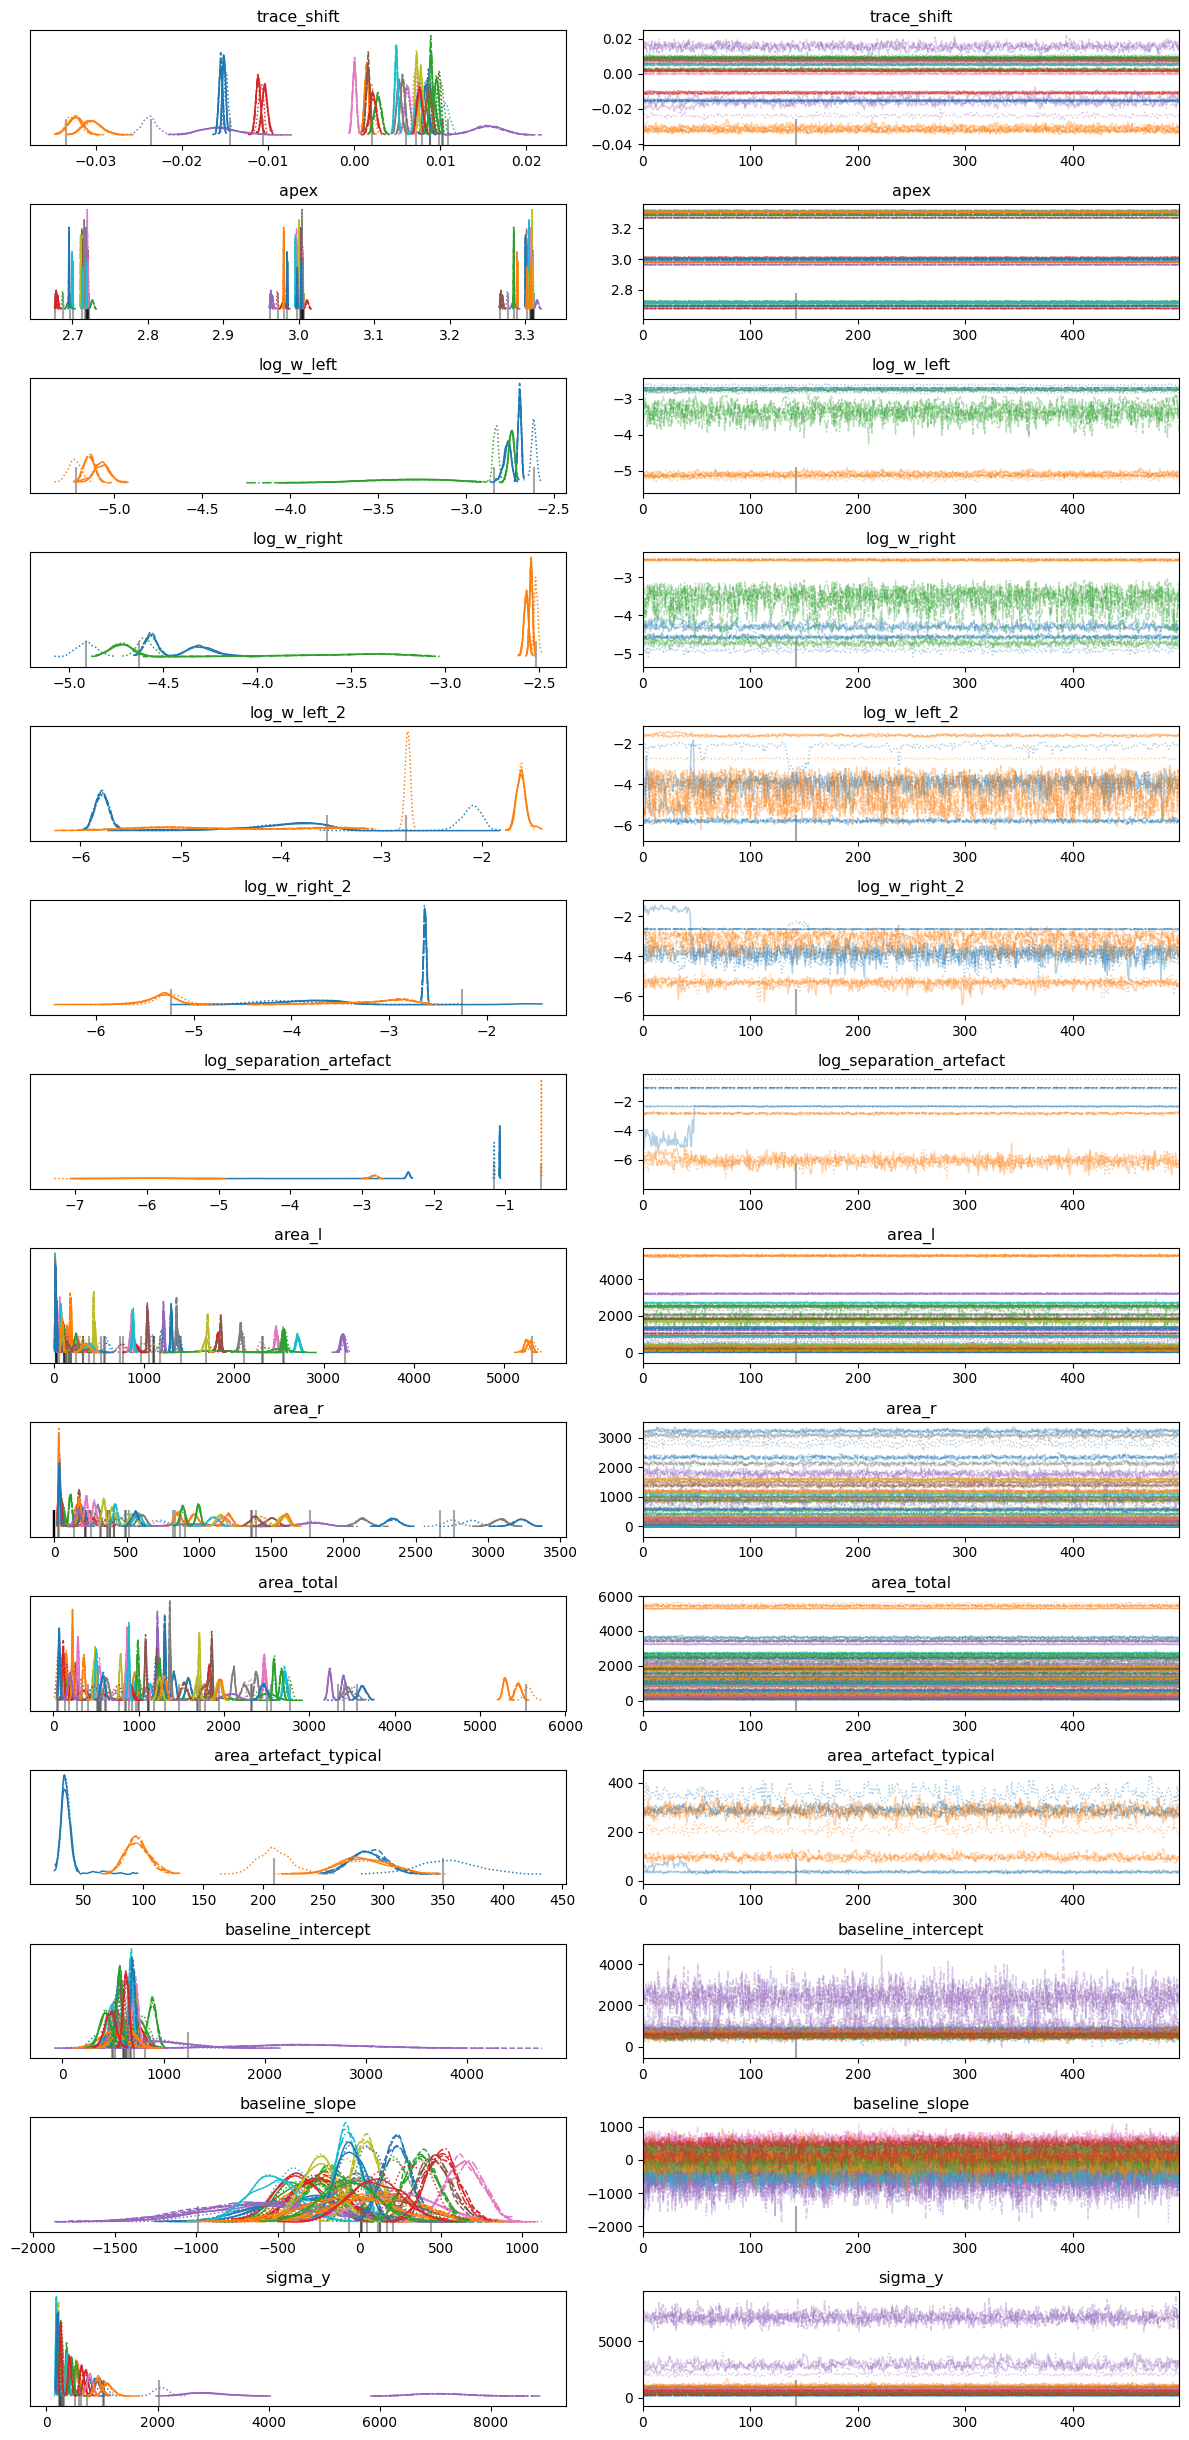

In [8]:
from chromhandler.fitting.better_visualize import plot_trace

SUMMARY_PARAMETER_NAMES = (
    "trace_shift",
    "apex",
    "log_w_left",
    "log_w_right",
    "log_w_left_2",
    "log_w_right_2",
    "log_separation_artefact",
    "log_separation_free",
    "area_l",
    "area_r",
    "area_total",
    "area_artefact_typical",
    "baseline_intercept",
    "baseline_slope",
    "sigma_y",
)
# single-subset fit


# or multi-subset fit
# posterior = fitter.posteriors["my_subset_name"]

fig = plot_trace(fitter.posterior, var_names=SUMMARY_PARAMETER_NAMES)
plt.show()



(
    <Figure size 800x350 with 1 Axes>,
    array([<Axes: title={'left': 'CV10'}, xlabel='time [min]', ylabel='signal [AU]'>],
      dtype=object)
)

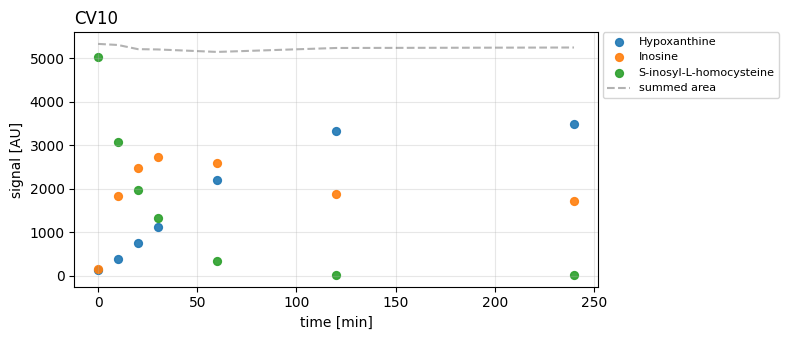

In [ ]:
handler.write_fitted_peaks(fitter)
handler.plot(show_balance=True)

In [ ]:
fitter.posterior

AttributeError: 'BetterFitter' object has no attribute 'posterior'

In [ ]:
handler.calibrate_molecules()


{
    'Ino': LinearCalibration(
        method=<CalibrationMethod.EXTERNAL: 'external'>,
        fit_intercept=False,
        slope=111.3624632123885,
        intercept=0.0,
        r_squared=0.999707781225277,
        residual_std=289.8842712318449,
        n_standards=22,
        max_area=67402.109375,
        min_area=62.07905578613281,
        max_conc=600.0,
        min_conc=0.0,
        slope_samples=[],
        intercept_samples=[],
        conc_unit="id='umol / l' name='umol / l' base_units=[BaseUnit(kind=<UnitType.MOLE: 'mole'>, exponent=1, multiplier=1.0, scale=-6.0), BaseUnit(kind=<UnitType.LITRE: 'litre'>, exponent=-1, multiplier=1.0, scale=0.0)]",
        chromatogram_ids=[
            'CV10_0min',
            'CV11_0min',
            'CV12_0min',
            'CV13_0min',
            'CV6_0min',
            'CV7_0min',
            'CV8_0min',
            'CV9_0min',
            'CW10_0min',
            'CW11_0min',
            'CW12_0min',
            'CW13_0min',
       

In [ ]:
[i.id for i in handler.molecules]

['Ino', 'SIH', 'Hyp']

In [ ]:
doc = handler.to_enzymeml(
    name="SAHH kinetics HPLC",
    temperature=25,
    temperature_unit="deg_C",
    ph=7.4,
    to_concentration=True,
)


NameError: name 'handler' is not defined